In [1]:
import numpy as np
import matplotlib.pyplot as plt

We will discuss the Dirichlet distribution, and revisit the Bayesian bootstrap comparing it with the classical bootstrap. 

## How to simulate from the Dirichlet distribution?

Consider the Dirichlet distribution with parameters $a_1, \dots, a_k$. Let us assume that $a_1, \dots, a_k$ are all strictly positive. We will occasionally take some of the $a_j$-s to be small to mimic the effect of them being exactly zero. 

The Dirichlet distribution is a distribution on probability vectors $(p_1, \dots, p_k)$ (probability vector means that each $p_j \geq 0$ and $\sum_{j=1}^k p_j = 1$). In other words, if we simulate from the Dirichlet distribution, we obtain probability vectors. 

In [2]:
a = np.array([1, 2, 1])
k = len(a)
dir_samples = np.random.dirichlet(a, size = 5) 
print(dir_samples)
#each row of dir_samples is a probability vector of length k that sums to 1. We can verify this by summing across the rows:
print(np.sum(dir_samples, axis=1))

[[0.0859347  0.28264365 0.63142164]
 [0.43933236 0.4541962  0.10647143]
 [0.26448836 0.18113413 0.55437751]
 [0.6929467  0.16510379 0.14194951]
 [0.06306947 0.65545811 0.28147242]]
[1. 1. 1. 1. 1.]


When $k = 3$, we can visualize probability vectors as points in the triangle with vertices $(1, 0, 0)$ (corresponding to $p_1 = 1$), $(0, 1, 0)$ (corresponding to $p_2 = 1$) and $(0, 0, 1)$ (corresponding to $p_3 = 1$). This is done below. 

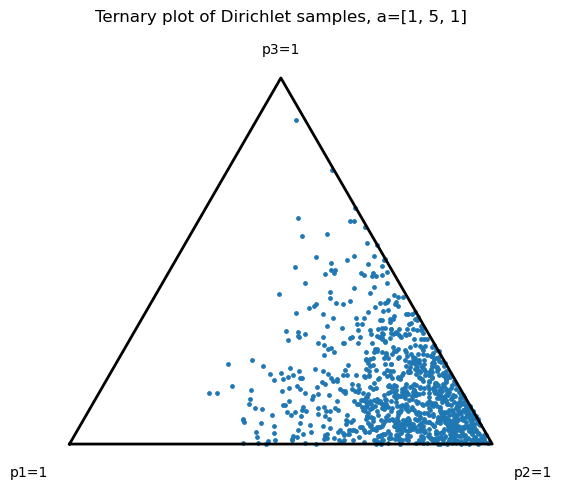

In [12]:
N = 1000
# a = np.array([0.0002, 0.0002, 0.0002])
# a = np.array([1, 1, 1])
a = np.array([1, 5, 1])
# a = np.array([0.00002, 1, 1])
P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "p1=1", ha="right", va="top")
plt.text( 1.05, -0.05, "p2=1", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "p3=1", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")
plt.show()

From the above plot (with varying $a_1, a_2, a_3$), the following observations can be made: 
1. When $a_i = 1$ for all $i$, the generated probability vector samples are uniformly distributed over the triangle (when $k \geq 3$ the triangle is referred to as the probability simplex). 
2. When $a_1 = 1 = a_3$ and $a_2 = 5$ is large, then the probability vectors are piled up near the corner corresponding to $p_2 = 1$. 
3. When $a_i = \epsilon$ for a small $\epsilon$ (e.g., $\epsilon = 0.0002$), the points are basically superimposed on the corners of the triangle. 
4. When $a_1 = \epsilon$ and $a_2 = a_3 = 1$, then $p_1$ will always be very nearly zero. So the points will be on the line joining the $p_2 = 1$ and $p_3 = 1$ corners. The probability vectors here can be seen as being supported only on the two coordinates $2$ and $3$. 

Now let us how exactly to simulate from the Dirichlet $(a_1, \dots, a_k)$ distribution (in other words, what is the code underlying numpy's np.random.dirichlet). One can use Gamma distributed random variables to obtain Dirichlet samples. We discuss this below. Let us first recall basic facts about Gamma distributions. Suppose $X_i \overset{\text{ind}}{\sim} \text{Gamma}(\text{shape} = a_i, \text{rate} = 1)$ for $i = 1, \dots, n$. Recall that the Gamma distribution with shape $a$ and rate $\lambda$ has the density: 
\begin{align*}
    x \mapsto \frac{\lambda^a}{\Gamma(a)} x^{a-1} \exp(-\lambda x) I\{x > 0\} ~~ \text{ where } ~~ \Gamma(a) := \int_0^{\infty} x^{a-1} e^{-x} dx. 
\end{align*}
We will only be using Gamma distributions with rate parameter set to 1 (i.e., $\lambda = 1$). In this case, the Gamma density becomes: 
\begin{align*}
   x \mapsto \frac{1}{\Gamma(a)} x^{a-1} e^{-x} I\{x > 0\}. 
\end{align*}
The simplest $\text{Gamma}(a, \lambda)$ density correspnds to $a = 1$ and it is the standard exponential density $\text{Gamma}(1, \lambda) = \text{Exp}(\lambda)$ with density function $\lambda \exp(-\lambda x) I\{x > 0\}$. In particular, $\text{Gamma}(1, 1)$ is $\text{Exp}(1)$ with density $\exp(-x) I\{x > 0\}$. 

Now we can state the connection between Dirichlet $(a_1, \dots, a_k)$ and Gamma random variables: 
\begin{align*}
 \left(\frac{X_1}{X_1 + \dots + X_k},  \dots, \frac{X_k}{X_1 + \dots + X_k} \right) \sim \text{Dirichlet}(a_1, \dots, a_k)
\end{align*}
provided
\begin{align*}
    X_i \overset{\text{ind}}{\sim} \text{Gamma}(a_i, 1). 
\end{align*}
In other words, to generate a probability vector from the Dirichlet $(a_1, \dots, a_k)$ distribution, we simply generate independent Gamma $(a_i, 1)$ distributed random variables, and then normalize them (by dividing each of them with their sum) to get a probability vector. 

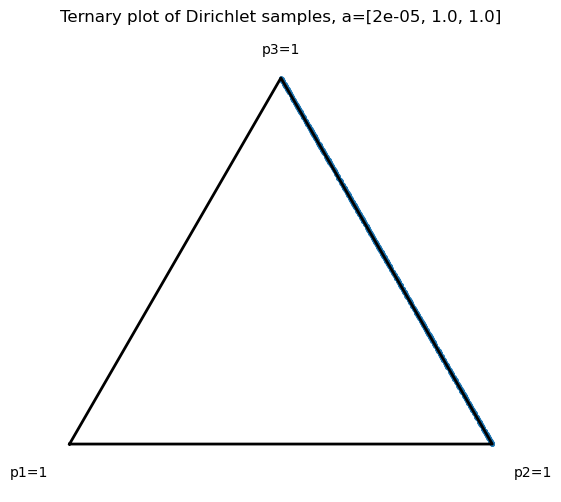

In [16]:
N = 1000
# a = np.array([0.0002, 0.0002, 0.0002])
# a = np.array([1, 1, 1])
# a = np.array([1, 5, 1])
a = np.array([0.00002, 1, 1])
# a = np.array([1, 2, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "p1=1", ha="right", va="top")
plt.text( 1.05, -0.05, "p2=1", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "p3=1", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")
plt.show()

This Dirichlet-Gamma connection can be used to understand some of the facts about Dirichlet $(a_1, \dots, a_k)$ stated previously. For example, suppose all the $a_i$'s are equal to a small number i.e., $a_i = \epsilon$ for all $i$. Then it turns out that the if we generate $X_i \sim \text{Gamma}(\epsilon, 1), i = 1, \dots, k$, the largest observation will be **much** larger than all of the others. This can be easily verified by simulation.

In [5]:
#simulate from Gamma distribution: 
a = 0.00002 #this is the shape parameter
lam = 1 #this is the rate parameter
n = 100
samples = np.random.gamma(shape=a, scale=1/lam, size=n)
print(np.sort(samples)[::-1])

[2.61773801e-197 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.000000

This clearly shows that when we normalize the generated Gamma values by their sum, the largest value will become 1 and all the other values will be near zero. Because any of the $k$ Gamma values can be the largest with equal probability, Dirichlet ($\epsilon, \dots, \epsilon$) with $\epsilon \downarrow 0$ will be uniformly distributed on $e_1, \dots, e_k$ where $e_i$ is the probability vector with $1$ in the $i$-th position and $0$ otherwise. 

In [6]:
print(samples/np.sum(samples))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


## The Bayesian Bootstrap

### Coin Tossing


The Bayesian bootstrap can be understood with the following very simple example: Suppose a coin is tossed twice resulting in one head and one tail. What can then be said about the coin's probability $p$ of landing heads?

Bayesian inference with the prior $p \sim \text{Beta}(a, b)$ gives the answer: $p \mid \text{data} \sim \text{Beta}(a + 1, b + 1)$. This answer depends on $a$ and $b$. If we take $a = 0$ and $b = 0$, then we get the posterior $\text{Beta}(1, 1)$, which is same as the uniform distribution on $(0, 1)$. This means that (after seeing the data of 1 head and 1 tail), our uncertainty is spread equally among all the values of $p$. For example, $p \in (0.9, 1)$ has the same posterior probability as $p \in (0, 0.1)$ as well as $(0.45, 0.55)$. This wide uncertainty can be attributed to the fact that we have only observed the results of 2 coin tosses which resulted in 1 heads and 1 tails. If we get more data, then the posterior will get narrower. 

An interesting feature of the $\text{Beta}(0, 0)$ prior is the following. Suppose we only observe 1 coin toss which resulted in a heads. Then the posterior of $p$ is $\text{Beta}(1, 0)$ which is concentrated at 1. This means that we are fully confident that $p = 1$. 

This might appear quite peculiar because after 1 toss, we have a fully confident concentrated posterior, but after two tosses (which resulted in two different outcomes), we have a very flat posterior. 

Jaynes (Subsection 12.4.3) explains this phenomenon using the following analogy. Imagine ordering coffee at a cafe and looking for sugar. You see a jar containing a white granular substance. You taste a single granule and find it sweet. You then you immediately conclude all the granules in the jar are sweet. This corresponds to the $n = 1$ fully concentrated posterior above. But suppose you sample another granule and it turns out to be salty, then you are fully confused and have no idea how much proportion of granules in the jar are sweet and how much proportion are salty. Then your posterior on the proportion of sugar granules in the jar is the uniform distribution on $(0, 1)$.

It is important to specially note that the posterior after 1 head and 1 tail is not concentrated at the observed proportion $1/2$. Rather, it is fully diffuse and uniform over the entire interval $(0, 1)$. 

### Rolling dice

The same phenomenon applies in the Dirichlet case. Suppose we roll a six-faced die six times and observe each face exactly once. What then can we say about the probabilities $p_1, \dots, p_k$ ($k = 6$) associated with the six die faces? If our prior is $(p_1, \dots p_k) \sim \text{Dirichlet}(0, \dots, 0)$, then the posterior is $\text{Dirichlet}(1, \dots, 1)$. This means that we are fully uncertain about the probabilities and have assigned a uniform posterior for all probability vectors of length $6$. 

### Numerical Measurements

The same ideas can be applied more generally. Consider the following problem (simpler case of problem discussed in Lectures 12 and 13):  A scientist is repeatedly running an experiment which produced the observations $26.6, 38.5, 34.4$ in the first three runs. Based on these, what can we say about the probabilities with which the experiment produces various observations?

The idea is to treat this problem as the die rolling problem. In the die rolling problem, the total number of outcomes is 6. Now, we consider a much larger set of outcomes, say, $\{0, 0.1, 0.2, \dots, 99.8, 99.9, 100\}$ ($k$ is the size of this set). The experiment has been repeated three times resulting in the three distinct outcomes $26.6, 38.5, 34.4$. The goal is to estimate the probabilities $p_1, p_2, \dots, p_k$ where $p_i$ is the probability associated with the $i$-th outcome in the set $\{0, 0.1, 0.2, \dots, 99.8, 99.9, 100\}$.

The prior on $(p_1, \dots, p_k)$ is $\text{Dirichlet}(0, \dots, 0)$ and the posterior will be $\text{Dirichlet}(a_1, \dots, a_k)$ where $a_i$ equals zero for all $i$ except when the outcome is actually observed (in this case, $a_i$ will be 1). So the posterior is supported on probability vectors $(p_1, \dots, p_k)$ for which $p_i \neq 0$ only when $i$ is observed. So the posterior can be viewed as being supported on probability vectors on the three outcome space $\{26.6, 38.5, 34.4\}$. Further, the posterior is uniform on these three-outcome probability vectors: 
\begin{align*}
    \text{posterior}(p) = w_1 \delta_{\{26.6\}} + w_2 \delta_{\{38.5\}} + w_3 \delta_{\{34.4\}} ~~ \text{ with } (w_1, w_2, w_3) \sim \text{Dirichlet}(1, 1, 1). 
\end{align*}
This posterior refuses to consider any outcome that has not been actually been observed. However, on the observed outcomes, it is displaying maximal posterior uncertainty by allowing all weights with equal probability. 

The code below generates posterior samples. 

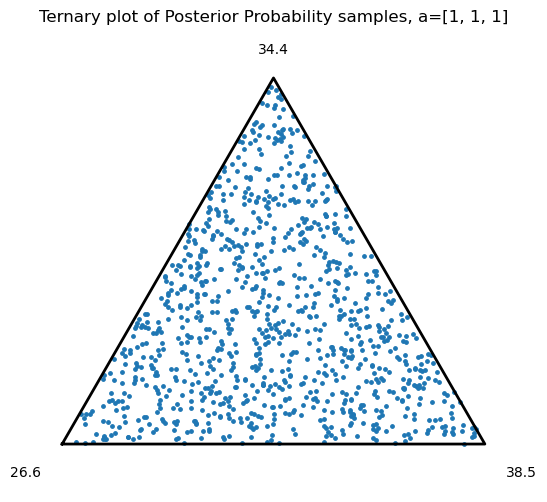

In [7]:
N = 1000
a = np.array([1, 1, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Posterior Probability samples, a={a.tolist()}")
plt.show()

The posterior samples are uniformly distributed over the entire probability triangle. 

### Comparison to classical bootstrap samples

In the classical bootstrap, one obtains re-samples by sampling with replacement from the observed data. 

In [8]:
bootstrap_samples = np.random.choice(np.array([26.6, 38.5, 34.4]), size=(10, 3), replace=True)
print(bootstrap_samples)

[[38.5 26.6 34.4]
 [26.6 34.4 38.5]
 [38.5 38.5 34.4]
 [38.5 26.6 34.4]
 [26.6 26.6 26.6]
 [34.4 34.4 26.6]
 [34.4 26.6 38.5]
 [26.6 38.5 34.4]
 [34.4 34.4 38.5]
 [34.4 38.5 38.5]]


Note that the order of numbers in each bootstrap sample is irrelevant. Each bootstrap sample contains a subset of the three observed numbers $26.6, 38.5, 34.4$. We can obtain an equivalent representation of the bootstrap samples by simply tracking the proportion of times 26.6 appears in the sample, the proportion of times 38.5 appears and the proportion of times 34.4 appears. For example, in this tracking scheme, the bootstrap sample $34.4, 34.4, 26.6$ becomes $1/3, 0, 2/3$. Note that these proportions (because they are nonnegative and sum to one) can also be viewed as probability vectors, so they can be plotted on the probability triangle. This is done below. 

In [9]:
N = 1000
bootstrap_samples = np.random.choice(np.array([26.6, 38.5, 34.4]), size=(N, 3), replace=True)
values = np.array([26.6, 38.5, 34.4])
proportion_samples = (bootstrap_samples[..., None] == values).mean(axis=1)
print(proportion_samples)

[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.66666667 0.        ]
 [0.66666667 0.         0.33333333]
 ...
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]]


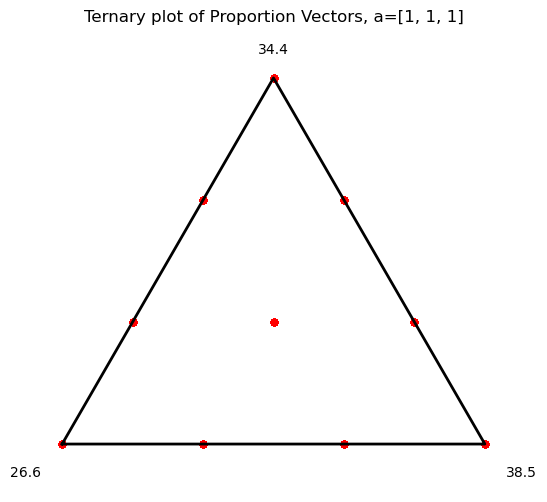

In [10]:
P = proportion_samples
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=20, alpha=1, color = 'red')

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Proportion Vectors, a={a.tolist()}")
plt.show()

Here we see the discrete nature of the classical bootstrap samples. The proportion vectors take only 10 distinct values (even though we generated $N = 1000$ of these proportion vectors). Below we plot both the Bayesian bootstrap posterior probability vectors and the classical bootstrap proportion vectors in the same plot. 

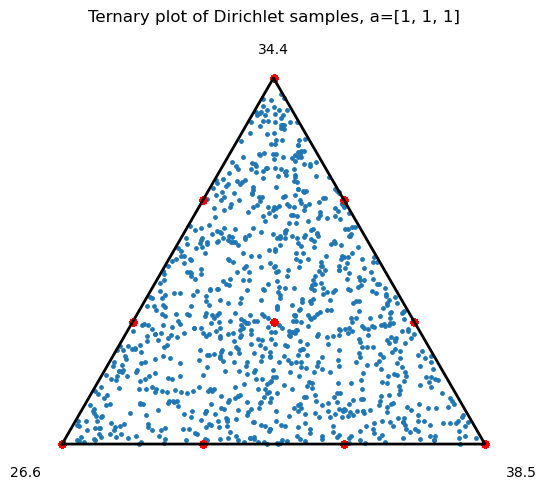

In [11]:
N = 1000
a = np.array([1, 1, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")

P = proportion_samples
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])


plt.scatter(x, y, s=20, alpha=1, color = 'red')

plt.show()

For classical bootstrap, we can generate the proportion vectors directly without actually resampling original data. This is because each proportion vector is itself distributed according to the following distribution: 
\begin{align*}
   (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}


In [12]:
prop_vectors = (np.random.multinomial(3, pvals=[1/3, 1/3, 1/3], size=N))/3
print(prop_vectors)

[[0.66666667 0.33333333 0.        ]
 [0.33333333 0.66666667 0.        ]
 [0.         0.66666667 0.33333333]
 ...
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.66666667 0.        ]
 [0.66666667 0.33333333 0.        ]]


In practice, the goal in these kinds of problems is not to estimate the whole probability distribution of the experiment generating the observations, but instead, to estimate some parameter such as the mean or median $\theta$ of that probability distribution. In each of these methods (classical bootstrap or Bayesian bootstrap), posterior samples for $\theta$ are obtained by calculating the mean or mode for each bootstrap sample. 

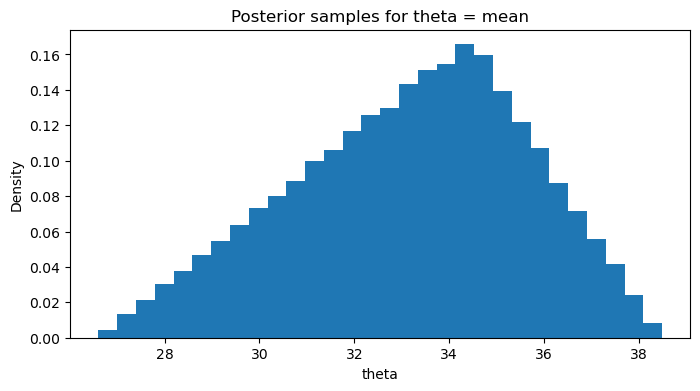

33.166666666666664 33.164271556243996


In [13]:
#Posterior samples for theta = mean
x_obs = np.array([26.6, 38.5, 34.4])
n = len(x_obs)
M = 100000
W = np.random.dirichlet(alpha=np.ones(n), size=M)
theta_samples = W @ x_obs
plt.figure(figsize=(8, 4))
plt.hist(theta_samples, bins=30, density=True)
plt.title("Posterior samples for theta = mean")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()
print(np.mean(x_obs), np.mean(theta_samples))

It is interesting that the posterior of $\theta$ is not uniform over its range, even though the posterior of $(w_1, w_2, w_3)$ was uniform over all probability vectors of length 3. The posterior of $\theta$ is peaked near the mean of the observed data. 

Next we plot the sample of $\theta$ obtained from classical bootstrap. 

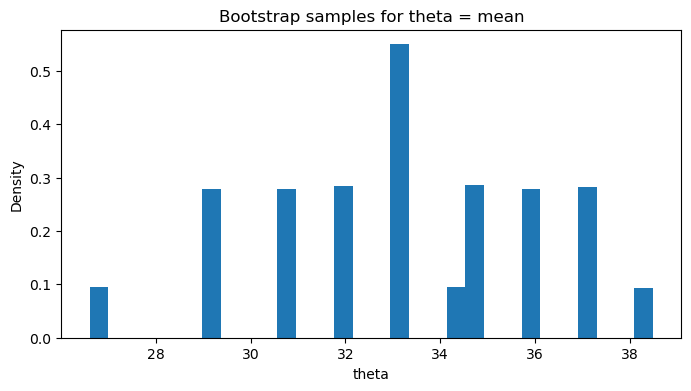

33.166666666666664 33.164271556243996


In [14]:
#Posterior samples for theta = mean
x_obs = np.array([26.6, 38.5, 34.4])
n = len(x_obs)
M = 100000
V = np.random.multinomial(n = n, pvals = np.ones(n)/n, size=M)/n
theta_samples_b = V @ x_obs
plt.figure(figsize=(8, 4))
plt.hist(theta_samples_b, bins=30, density=True)
plt.title("Bootstrap samples for theta = mean")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()
print(np.mean(x_obs), np.mean(theta_samples))

The classical bootstrap histogram for $\theta$ appears very choppy. This is because of its discrete nature and the fact that we have only 3 observations here. It is also not uniform, and is peaked at the mean of the observed data. 

When $n$ is large, both Bayesian bootstrap and the classical bootstrap will give similar results. 

## Ice Cream Problem

Suppose you and a friend are planning to open an ice cream shop. You will sell three kinds of ice cream: Vanilla, Chocolate and Coffee. In the first week of opening, you sell
- 19 Vanilla, 
- 49 Chocolate, and
- 29 Coffee ice creams. 

### Problem 1
Using a Bayesian model, which proportion of each of the three flavors should you buy for the next week? You may assume that at the beginning of the week, you were unsure which ice cream would sell best (e.g., use a $\textsf{Uniform}$ prior).

### Problem 2
Suppose you friend wants to make a bet with you: 
- If the next customer buys a chocolate ice cream, you will pay your friend $\$20$. 
- If the next customer buys a vanilla ice cream, your friend will pay you $\$10$. 
- If the next customer buys a coffee ice cream, nothing happens. 

Should you take the bet? 

### Problem 1 Solution
For this problem, we use the $\textsf{Dirichlet}-\textsf{Multinomial}$ model with a $\textsf{Uniform}$ prior:
\begin{align*}
    (p_1,p_2,p_3) &\sim \textsf{Dirichlet}(1,1,1) &\text{(Prior)} \\ 
    (X_1,X_2,X_3) \mid p_1,p_2,p_3 &\sim \textsf{Multinomial}(n;p_1,p_2,p_3) &\text{(Likelihood)} \\ 
    (p_1,p_2,p_3) \mid \text{data} &\sim \textsf{Dirichlet}(1+x_1, 1+x_2, 1+x_3) &\text{(Posterior)} \\ 
\end{align*}
where $p_1,p_2,p_3$ represent the proportion of Vanilla, Chocolate and Coffee flavored ice cream. 

We can use the posterior mean as a reasonable estimate for what proportion of ice cream flavor we should order for next week: 
\begin{align*}
    \mathbb{E}[p_i\mid \text{data}] = \frac{x_i+1}{1+x_1+1+x_2+1+x_3} = \frac{x_i+1}{n+3}
\end{align*}
Therefore, we should order $2/10, 5/10, 3/10$ proportion of Vanilla, Chocolate and Coffee flavored ice cream for next week. 

### Problem 2 Solution

For this problem, we will consider the Posterior Predictive Distribution.
\begin{align*}
    \mathbb{P}\left\{ X_1^{(\text{next})} = 1, X_2^{(\text{next})} = 0, X_3^{(\text{next})} = 0 \mid \text{data} \right\}
    =
    \mathbb{P}\left\{ \vec{X}^{(\text{next})} = (1,0,0) \mid \text{data} \right\}
\end{align*}
Applying the law of total probability, we have 
\begin{align*}
    \mathbb{P}\left\{ \vec{X}^{(\text{next})} = (1,0,0) \mid \text{data} \right\} &=
    \int_{\text{all } \vec{p}}  
    \mathbb{P}\left\{ \vec{X}^{(\text{next})} = (1,0,0) \mid \text{data}, \vec{p} \right\}
    \times f_{\vec{p} \mid \text{data}}(\vec{p})
    \mathrm{d}\vec{p} \\
    &=
    \int_{\text{all } \vec{p}}  
    \underbrace{\mathbb{P}\left\{ \vec{X}^{(\text{next})} = (1,0,0) \mid \vec{p} \right\}}_{\text{Likelihood with }x_1 = n=1}
    \times \underbrace{f_{\vec{p} \mid \text{data}}(\vec{p})}_{\text{Posterior}}
    \mathrm{d}\vec{p} \\
    &=
    \int_{\text{all } \vec{p}}  
    \frac{1!}{1!0!0!} p_1^1 p_2^0 p_3^0
    \times f_{\vec{p} \mid \text{data}}(\vec{p})
    \mathrm{d}\vec{p} \\
    &=
    \int_{\text{all } \vec{p}}  
    p_1
    \times f_{\vec{p} \mid \text{data}}(\vec{p})
    \mathrm{d}\vec{p}
    \\
    &=
    \mathbb{E}\left[ p_1 \mid \text{data} \right]
\end{align*}
In this case, the posterior predictive distribution (of the next draw) is equal to the posterior mean. 

Using this result, the expected payoff of the proposed bet is
\begin{align*}
    \mathbb{E}\left[ \text{Bet} \right] = 
    \mathbb{E}\left[ \text{Bet} \mid \text{Win} \right] \mathbb{P}\left\{ \text{Win} \right\}
    + 
    \mathbb{E}\left[ \text{Bet} \mid \text{Lose} \right] \mathbb{P}\left\{ \text{Lose} \right\}
\end{align*}
where 
\begin{align*}
    \mathbb{P}\left\{ \text{Win} \right\}
    &= 
    \mathbb{P}\left\{ \vec{X}^{(\text{next})} = (1,0,0) \mid \text{data} \right\}
    = 
    \mathbb{E}\left[ p_1 \mid \text{data} \right] = \frac{2}{10}
    \\
    \mathbb{P}\left\{ \text{Lose} \right\}
    &= 
    \mathbb{P}\left\{ \vec{X}^{(\text{next})} = (0,1,0) \mid \text{data} \right\}
    = 
    \mathbb{E}\left[ p_2 \mid \text{data} \right] = \frac{5}{10}
\end{align*}
Plugging these probabilities in, we find that the expected payoff is $-\$8$, so we should $\textbf{not}$ take the bet.